<div style="text-align:center; padding: 22px 28px 10px 28px; font-family: 'Segoe UI', sans-serif; color:#113A5C;">
  
  <div style="display:inline-block; padding: 10px 18px; border-radius: 999px; background: linear-gradient(90deg, #EAF2FB, #EEF8E7); font-size: 14px; letter-spacing: 0.08em; text-transform: uppercase; color:#004E9A; font-weight:600;">
    INFB8090 - Computacion Paralela
  </div>
  <h1 style="margin: 18px 0 8px 0; font-size: 34px; color:#004E9A;">Laboratorio 3: Concurrencia en Python y benchmarking comparativo</h1>
  <p style="max-width: 920px; margin: 0 auto 16px auto; font-size: 16px; line-height: 1.65; color:#24435B;">
    Notebook experimental con ejercicios originales sobre GIL, threads, multiprocessing, asyncio y seleccion de estrategia segun tipo de carga.
  </p>
  <div style="display:grid; grid-template-columns: repeat(2, minmax(260px, 1fr)); gap:12px; max-width: 900px; margin: 20px auto 0 auto; text-align:left;">
    <div style="background:#FFFFFF; border:1px solid #D6E4F2; border-radius:18px; padding:16px 18px; box-shadow:0 10px 24px rgba(0,78,154,0.06);">
      <div style="font-size:12px; text-transform:uppercase; letter-spacing:0.08em; color:#6B7A88; margin-bottom:6px;">Integrantes</div>
      <div style="font-size:18px; font-weight:600; color:#113A5C;">Welinton Barrera<br/>Joaquin Araya</div>
    </div>
    <div style="background:#FFFFFF; border:1px solid #DCEBD0; border-radius:18px; padding:16px 18px; box-shadow:0 10px 24px rgba(122,184,48,0.08);">
      <div style="font-size:12px; text-transform:uppercase; letter-spacing:0.08em; color:#6B7A88; margin-bottom:6px;">Docencia</div>
      <div style="font-size:18px; font-weight:600; color:#113A5C;">Dr. Ing. Michael Miranda Sandoval<br/>Seccion 412</div>
    </div>
  </div>
  <div style="margin-top:18px; font-size:14px; color:#5B6B77;">
    Universidad Tecnologica Metropolitana | Primer semestre 2026
  </div>
</div>

## Contexto y objetivo

Este notebook fue construido para **no repetir los ejemplos del PDF**, pero si responder exactamente a los aprendizajes del Laboratorio 3:

- distinguir cargas `CPU-bound`, `I/O-bound` y mixtas;
- comparar secuencial, `threads`, `processes` y `asyncio` con criterio experimental;
- interpretar el rol del `GIL` y de otros overheads;
- formular una recomendacion tecnica defendible para un problema nuevo.

Los tres desafios del laboratorio se resolvieron con escenarios propios:

1. bloques sinteticos de telemetria para observar el GIL en una carga CPU-bound y contrastarlo con un caso I/O-bound;
2. benchmark comparativo entre secuencial, hilos y procesos sobre una tarea de computo intensivo;
3. escenario mixto con espera y postprocesamiento local para evaluar `asyncio` y cerrar con una recomendacion global.

In [1]:
import asyncio
import hashlib
import json
import os
import platform
import statistics
import time
from concurrent.futures import ProcessPoolExecutor, ThreadPoolExecutor
from html import escape
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import HTML, Markdown, display

from lab3_workers import cpu_chunk_digest

sns.set_theme(style="whitegrid")
sns.set_palette(["#004E9A", "#7AB830", "#113A5C", "#A3D65C", "#3C91E6"])
plt.rcParams["figure.figsize"] = (10, 5.2)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["axes.facecolor"] = "#FAFCFE"
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["grid.alpha"] = 0.18
plt.rcParams["font.family"] = "DejaVu Sans"

ROOT = Path.cwd()
SUMMARY_PATH = ROOT / "_lab3_summary.json"

try:
    import psutil
except ImportError:
    psutil = None


def fmt_int(value):
    return f"{int(value):,}".replace(",", ".")


def fmt_seconds(value):
    return f"{value:.4f} s"


def fmt_ratio(value):
    return f"{value:.2f}x"


def fmt_eff(value):
    return f"{value * 100:.1f}%"


def fmt_optional(value, pattern="{:.3f}"):
    if value is None or pd.isna(value):
        return "-"
    return pattern.format(value)


def callout(title, body, accent="#004E9A", bg="#F5F9FE"):
    display(
        HTML(
            f"""
            <div style="border-left:6px solid {accent}; background:{bg}; padding:14px 18px; margin:16px 0; border-radius:12px;">
              <div style="font-weight:700; color:#113A5C; margin-bottom:6px;">{escape(title)}</div>
              <div style="color:#304B5F; line-height:1.65;">{body}</div>
            </div>
            """
        )
    )


def metric_cards(items):
    cards = []
    for label, value, note, accent in items:
        cards.append(
            f"""
            <div style="background:white; border:1px solid #D8E4EF; border-top:5px solid {accent}; border-radius:16px; padding:14px 16px; box-shadow:0 10px 24px rgba(17,58,92,0.05);">
              <div style="font-size:12px; text-transform:uppercase; letter-spacing:0.08em; color:#72808D; margin-bottom:8px;">{escape(label)}</div>
              <div style="font-size:28px; font-weight:700; color:#113A5C; margin-bottom:6px;">{escape(value)}</div>
              <div style="font-size:13px; color:#4C6273;">{note}</div>
            </div>
            """
        )
    display(
        HTML(
            "<div style='display:grid; grid-template-columns:repeat(auto-fit, minmax(220px, 1fr)); gap:14px; margin:10px 0 18px 0;'>"
            + "".join(cards)
            + "</div>"
        )
    )


def show_df(df, caption, formats=None, gradient_cols=None):
    styler = (
        df.style.hide(axis="index")
        .set_caption(caption)
        .set_table_styles(
            [
                {
                    "selector": "caption",
                    "props": [
                        ("caption-side", "top"),
                        ("text-align", "left"),
                        ("font-size", "1.05rem"),
                        ("font-weight", "700"),
                        ("color", "#113A5C"),
                        ("padding", "0 0 8px 0"),
                    ],
                },
                {
                    "selector": "th",
                    "props": [
                        ("background-color", "#004E9A"),
                        ("color", "white"),
                        ("padding", "8px 10px"),
                        ("border", "1px solid #D8E4EF"),
                    ],
                },
                {
                    "selector": "td",
                    "props": [
                        ("padding", "8px 10px"),
                        ("border", "1px solid #D8E4EF"),
                    ],
                },
            ]
        )
    )
    if formats:
        styler = styler.format(formats)
    if gradient_cols:
        styler = styler.background_gradient(subset=gradient_cols, cmap="Blues")
    display(styler)


def benchmark(fn, repeats=5, warmups=1):
    for _ in range(warmups):
        fn()

    times = []
    result = None
    for _ in range(repeats):
        t0 = time.perf_counter()
        result = fn()
        times.append(time.perf_counter() - t0)

    return {
        "mean_s": statistics.fmean(times),
        "std_s": statistics.stdev(times) if len(times) > 1 else 0.0,
        "times": times,
        "result": result,
    }


async def benchmark_async(async_factory, repeats=5, warmups=1):
    for _ in range(warmups):
        await async_factory()

    times = []
    result = None
    for _ in range(repeats):
        t0 = time.perf_counter()
        result = await async_factory()
        times.append(time.perf_counter() - t0)

    return {
        "mean_s": statistics.fmean(times),
        "std_s": statistics.stdev(times) if len(times) > 1 else 0.0,
        "times": times,
        "result": result,
    }


def run_thread_map(function, items, workers):
    with ThreadPoolExecutor(max_workers=workers) as executor:
        return list(executor.map(function, items))


def run_process_map(function, items, workers):
    with ProcessPoolExecutor(max_workers=workers) as executor:
        return list(executor.map(function, items))


def to_json_records(df):
    return json.loads(df.to_json(orient="records"))

In [2]:
env_rows = [
    {"Campo": "Sistema operativo", "Valor": platform.platform()},
    {"Campo": "Version de Python", "Valor": platform.python_version()},
    {"Campo": "CPU logicos visibles", "Valor": os.cpu_count()},
    {"Campo": "RAM aproximada", "Valor": f"{psutil.virtual_memory().total / 1024**3:.2f} GB" if psutil else "No disponible"},
    {"Campo": "Librerias usadas", "Valor": "concurrent.futures, asyncio, pandas, seaborn, matplotlib"},
    {"Campo": "Directorio de trabajo", "Valor": str(ROOT)},
]
env_df = pd.DataFrame(env_rows)
show_df(env_df, "Configuracion experimental")

callout(
    "Diseno metodologico",
    "<ul style='margin:0; padding-left:18px;'>"
    "<li>Todos los tiempos se midieron con <code>time.perf_counter()</code>.</li>"
    "<li>Se aplico 1 warm-up y 5 repeticiones por configuracion.</li>"
    "<li>Las comparaciones usan exactamente la misma carga para cada estrategia.</li>"
    "<li>Para procesos en Windows se importan workers desde <code>lab3_workers.py</code>.</li>"
    "<li>Las cargas I/O y mixtas usan latencia simulada para mantener reproducibilidad y evitar depender de la red.</li>"
    "</ul>",
    accent="#7AB830",
    bg="#F3FAEC",
)

Campo,Valor
Sistema operativo,Windows-11-10.0.26200-SP0
Version de Python,3.13.5
CPU logicos visibles,16
RAM aproximada,15.26 GB
Librerias usadas,"concurrent.futures, asyncio, pandas, seaborn, matplotlib"
Directorio de trabajo,C:\Users\welin\Desktop\universidad\Paralela\lab3


## Desafio 1 - Distinguir experimentalmente entre CPU-bound e I/O-bound

El primer desafio busca comprobar una idea central de la semana: **la estrategia correcta depende del tipo de carga**. Primero se compara una tarea CPU-bound contra hilos y luego una tarea I/O-bound tambien contra hilos, para ver que el efecto del `GIL` no es uniforme.

### 1.a - Caso CPU-bound y evaluacion con hilos

**Caso propuesto:** digest sintetico de bloques de telemetria. Cada bloque ejecuta muchas iteraciones de aritmetica modular en Python puro. El objetivo es que el tiempo este dominado por computo local y que, por lo tanto, los hilos no entreguen mejora consistente.

Perfil,Bloques,Iteraciones por bloque,Salt
Pequeno,12,160.000,41
Mediano,12,300.000,41
Grande,12,500.000,41


Perfil,Bloques,Iteraciones por bloque,Secuencial (s),Hilos x8 (s),Desv. hilos (s),Speedup hilos,Eficiencia hilos
Pequeno,12,160.000,0.3084,0.3196,0.0015,0.97,0.121
Mediano,12,300.000,0.5888,0.5957,0.0037,0.99,0.124
Grande,12,500.000,0.9631,0.9922,0.0068,0.97,0.121


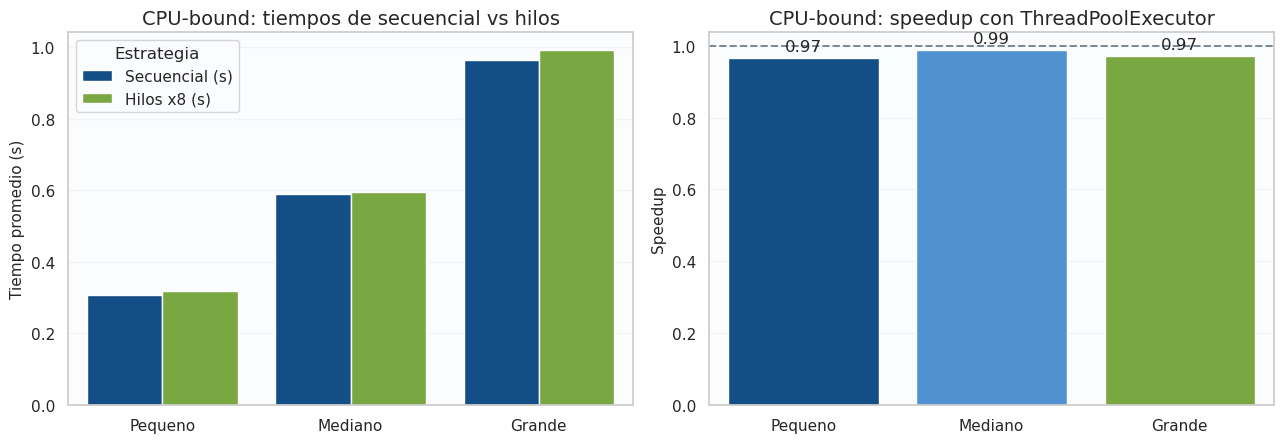

In [3]:
cpu_thread_profiles = [
    {"Perfil": "Pequeno", "Bloques": 12, "Iteraciones por bloque": 160_000, "Salt": 41},
    {"Perfil": "Mediano", "Bloques": 12, "Iteraciones por bloque": 300_000, "Salt": 41},
    {"Perfil": "Grande", "Bloques": 12, "Iteraciones por bloque": 500_000, "Salt": 41},
]
cpu_thread_meta = pd.DataFrame(cpu_thread_profiles)
show_df(
    cpu_thread_meta,
    "Parametros del caso CPU-bound para el desafio 1.a",
    formats={"Bloques": "{:.0f}", "Iteraciones por bloque": fmt_int, "Salt": "{:.0f}"},
)


def build_cpu_tasks(blocks, iterations, salt):
    return [(chunk_id, iterations, salt) for chunk_id in range(blocks)]


def run_cpu_seq(tasks):
    return [cpu_chunk_digest(task) for task in tasks]


def run_cpu_threads(tasks, workers=8):
    return run_thread_map(cpu_chunk_digest, tasks, workers)


d1a_rows = []
for profile in cpu_thread_profiles:
    tasks = build_cpu_tasks(profile["Bloques"], profile["Iteraciones por bloque"], profile["Salt"])
    seq_stats = benchmark(lambda tasks=tasks: run_cpu_seq(tasks))
    thread_stats = benchmark(lambda tasks=tasks: run_cpu_threads(tasks, workers=8))
    assert seq_stats["result"] == thread_stats["result"]

    speedup = seq_stats["mean_s"] / thread_stats["mean_s"]
    efficiency = speedup / 8

    d1a_rows.append(
        {
            "Perfil": profile["Perfil"],
            "Bloques": profile["Bloques"],
            "Iteraciones por bloque": profile["Iteraciones por bloque"],
            "Secuencial (s)": seq_stats["mean_s"],
            "Hilos x8 (s)": thread_stats["mean_s"],
            "Desv. hilos (s)": thread_stats["std_s"],
            "Speedup hilos": speedup,
            "Eficiencia hilos": efficiency,
        }
    )

d1a_df = pd.DataFrame(d1a_rows)
show_df(
    d1a_df,
    "Desafio 1.a - Secuencial vs hilos en una carga CPU-bound",
    formats={
        "Bloques": "{:.0f}",
        "Iteraciones por bloque": fmt_int,
        "Secuencial (s)": "{:.4f}",
        "Hilos x8 (s)": "{:.4f}",
        "Desv. hilos (s)": "{:.4f}",
        "Speedup hilos": "{:.2f}",
        "Eficiencia hilos": "{:.3f}",
    },
    gradient_cols=["Secuencial (s)", "Hilos x8 (s)", "Speedup hilos"],
)

best_d1a = d1a_df.loc[d1a_df["Speedup hilos"].idxmax()]
metric_cards(
    [
        ("Mejor speedup con hilos", fmt_ratio(best_d1a["Speedup hilos"]), f"Perfil: {best_d1a['Perfil']}", "#113A5C"),
        ("Eficiencia maxima", fmt_eff(d1a_df["Eficiencia hilos"].max()), "Muy baja para una carga de computo puro", "#004E9A"),
        ("Lectura principal", "Sin mejora consistente", "El GIL impide paralelismo efectivo de bytecode", "#7AB830"),
    ]
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
cpu_plot = d1a_df.melt(
    id_vars=["Perfil"],
    value_vars=["Secuencial (s)", "Hilos x8 (s)"],
    var_name="Estrategia",
    value_name="Tiempo",
)
sns.barplot(data=cpu_plot, x="Perfil", y="Tiempo", hue="Estrategia", ax=axes[0])
axes[0].set_title("CPU-bound: tiempos de secuencial vs hilos")
axes[0].set_ylabel("Tiempo promedio (s)")
axes[0].set_xlabel("")

sns.barplot(
    data=d1a_df,
    x="Perfil",
    y="Speedup hilos",
    hue="Perfil",
    dodge=False,
    legend=False,
    palette=["#004E9A", "#3C91E6", "#7AB830"],
    ax=axes[1],
)
axes[1].axhline(1.0, linestyle="--", linewidth=1.4, color="#7A8793")
axes[1].set_title("CPU-bound: speedup con ThreadPoolExecutor")
axes[1].set_ylabel("Speedup")
axes[1].set_xlabel("")
for container in axes[1].containers:
    axes[1].bar_label(container, fmt="%.2f", padding=3)

plt.tight_layout()
plt.show()

In [4]:
d1a_mean_speedup = d1a_df["Speedup hilos"].mean()
display(
    Markdown(
        f"""
        ### Interpretacion del desafio 1.a

        El mejor speedup con hilos fue de **{best_d1a['Speedup hilos']:.2f}x** y el promedio del caso fue **{d1a_mean_speedup:.2f}x**.
        En otras palabras, el uso de hilos sobre esta carga CPU-bound no entrega una mejora consistente. Eso es coherente con el
        **GIL de CPython**: aunque existan varios hilos, solo uno ejecuta bytecode Python a la vez dentro del proceso. El resultado
        puede variar levemente entre corridas, pero el patron general es claro: los hilos no aceleran de manera material una tarea
        de computo puro implementada en Python.

        Tecnica y metodologicamente, este experimento demuestra que no basta con "agregar concurrencia". Si la carga esta dominada
        por CPU y el trabajo sucede en Python puro, el beneficio esperado de `ThreadPoolExecutor` es muy bajo e incluso puede
        empeorar por cambio de contexto y overhead de coordinacion.
        """
    )
)


        ### Interpretacion del desafio 1.a

        El mejor speedup con hilos fue de **0.99x** y el promedio del caso fue **0.97x**.
        En otras palabras, el uso de hilos sobre esta carga CPU-bound no entrega una mejora consistente. Eso es coherente con el
        **GIL de CPython**: aunque existan varios hilos, solo uno ejecuta bytecode Python a la vez dentro del proceso. El resultado
        puede variar levemente entre corridas, pero el patron general es claro: los hilos no aceleran de manera material una tarea
        de computo puro implementada en Python.

        Tecnica y metodologicamente, este experimento demuestra que no basta con "agregar concurrencia". Si la carga esta dominada
        por CPU y el trabajo sucede en Python puro, el beneficio esperado de `ThreadPoolExecutor` es muy bajo e incluso puede
        empeorar por cambio de contexto y overhead de coordinacion.
        

### 1.b - Caso I/O-bound y evaluacion con hilos

**Caso propuesto:** lectura sintetica de manifiestos de telemetria. Cada tarea espera una latencia controlada y luego valida un checksum liviano. Aqui el tiempo esta dominado por espera, asi que los hilos deberian solapar esa latencia.

Perfil,Tareas,Latencia base (s)
12 manifiestos,12,0.030
24 manifiestos,24,0.030
36 manifiestos,36,0.030


Perfil,Tareas,Secuencial (s),Hilos x8 (s),Desv. hilos (s),Speedup hilos,Eficiencia hilos
12 manifiestos,12,0.4494,0.0796,0.0006,5.65,0.706
24 manifiestos,24,0.9139,0.1333,0.0004,6.85,0.857
36 manifiestos,36,1.3764,0.1938,0.0006,7.10,0.888


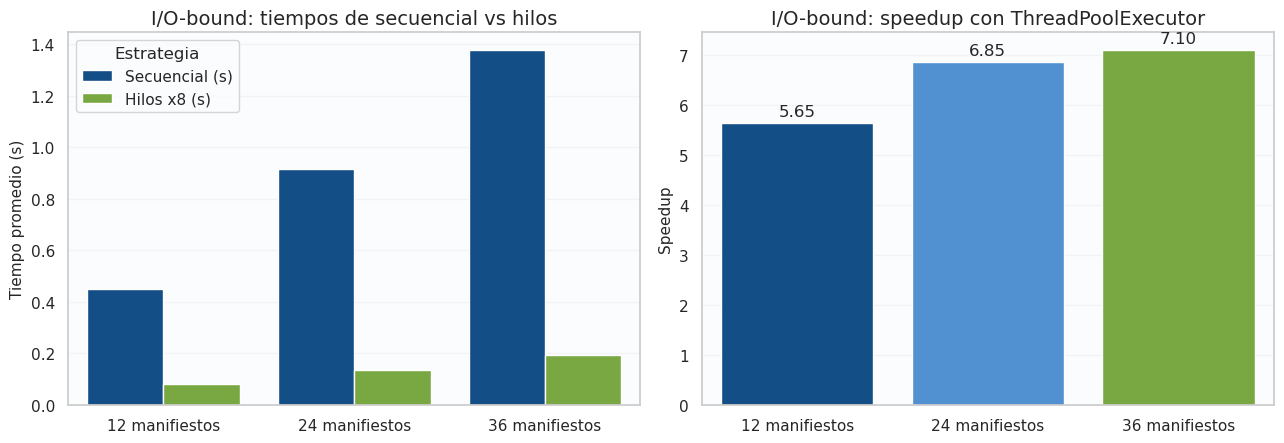

In [5]:
io_thread_profiles = [
    {"Perfil": "12 manifiestos", "Tareas": 12, "Latencia base (s)": 0.030},
    {"Perfil": "24 manifiestos", "Tareas": 24, "Latencia base (s)": 0.030},
    {"Perfil": "36 manifiestos", "Tareas": 36, "Latencia base (s)": 0.030},
]
io_thread_meta = pd.DataFrame(io_thread_profiles)
show_df(
    io_thread_meta,
    "Parametros del caso I/O-bound para el desafio 1.b",
    formats={"Tareas": "{:.0f}", "Latencia base (s)": "{:.3f}"},
)


def io_manifest(task_id):
    time.sleep(0.030 + (task_id % 5) * 0.004)
    payload = f"sensor-{task_id}|manifest|telemetry".encode("utf-8")
    digest = hashlib.sha256(payload).hexdigest()
    return task_id, digest[:12], sum(int(char, 16) for char in digest[:16])


def run_io_seq(tasks):
    return [io_manifest(task_id) for task_id in tasks]


def run_io_threads(tasks, workers=8):
    return run_thread_map(io_manifest, tasks, workers)


d1b_rows = []
for profile in io_thread_profiles:
    tasks = list(range(profile["Tareas"]))
    seq_stats = benchmark(lambda tasks=tasks: run_io_seq(tasks))
    thread_stats = benchmark(lambda tasks=tasks: run_io_threads(tasks, workers=8))
    assert seq_stats["result"] == thread_stats["result"]

    speedup = seq_stats["mean_s"] / thread_stats["mean_s"]
    efficiency = speedup / 8

    d1b_rows.append(
        {
            "Perfil": profile["Perfil"],
            "Tareas": profile["Tareas"],
            "Secuencial (s)": seq_stats["mean_s"],
            "Hilos x8 (s)": thread_stats["mean_s"],
            "Desv. hilos (s)": thread_stats["std_s"],
            "Speedup hilos": speedup,
            "Eficiencia hilos": efficiency,
        }
    )

d1b_df = pd.DataFrame(d1b_rows)
show_df(
    d1b_df,
    "Desafio 1.b - Secuencial vs hilos en una carga I/O-bound",
    formats={
        "Tareas": "{:.0f}",
        "Secuencial (s)": "{:.4f}",
        "Hilos x8 (s)": "{:.4f}",
        "Desv. hilos (s)": "{:.4f}",
        "Speedup hilos": "{:.2f}",
        "Eficiencia hilos": "{:.3f}",
    },
    gradient_cols=["Secuencial (s)", "Hilos x8 (s)", "Speedup hilos"],
)

best_d1b = d1b_df.loc[d1b_df["Speedup hilos"].idxmax()]
metric_cards(
    [
        ("Mejor speedup con hilos", fmt_ratio(best_d1b["Speedup hilos"]), f"Perfil: {best_d1b['Perfil']}", "#004E9A"),
        ("Eficiencia maxima", fmt_eff(d1b_df["Eficiencia hilos"].max()), "Los hilos si aprovechan la espera", "#7AB830"),
        ("Lectura principal", "Latencia solapada", "El GIL no impide progreso util cuando domina la espera", "#113A5C"),
    ]
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
io_plot = d1b_df.melt(
    id_vars=["Perfil"],
    value_vars=["Secuencial (s)", "Hilos x8 (s)"],
    var_name="Estrategia",
    value_name="Tiempo",
)
sns.barplot(data=io_plot, x="Perfil", y="Tiempo", hue="Estrategia", ax=axes[0])
axes[0].set_title("I/O-bound: tiempos de secuencial vs hilos")
axes[0].set_ylabel("Tiempo promedio (s)")
axes[0].set_xlabel("")

sns.barplot(
    data=d1b_df,
    x="Perfil",
    y="Speedup hilos",
    hue="Perfil",
    dodge=False,
    legend=False,
    palette=["#004E9A", "#3C91E6", "#7AB830"],
    ax=axes[1],
)
axes[1].set_title("I/O-bound: speedup con ThreadPoolExecutor")
axes[1].set_ylabel("Speedup")
axes[1].set_xlabel("")
for container in axes[1].containers:
    axes[1].bar_label(container, fmt="%.2f", padding=3)

plt.tight_layout()
plt.show()

In [6]:
display(
    Markdown(
        f"""
        ### Interpretacion del desafio 1.b

        En este caso los hilos si mostraron una mejora clara. El mejor resultado aparecio en **{best_d1b['Perfil']}** con
        **{best_d1b['Speedup hilos']:.2f}x** de speedup y **{best_d1b['Eficiencia hilos'] * 100:.1f}%** de eficiencia. La
        diferencia respecto del caso CPU-bound confirma el punto teorico revisado en clases: **los hilos no son inutiles en Python**;
        simplemente no son la herramienta adecuada para computo puro bajo GIL. Cuando la carga esta dominada por espera, el
        interprete puede ceder ejecucion a otros hilos y el tiempo muerto se solapa.

        En otras palabras, el cambio de comportamiento entre 1.a y 1.b no es una contradiccion: es precisamente la evidencia
        experimental de que el tipo de carga determina si `threading` tiene o no sentido.
        """
    )
)


        ### Interpretacion del desafio 1.b

        En este caso los hilos si mostraron una mejora clara. El mejor resultado aparecio en **36 manifiestos** con
        **7.10x** de speedup y **88.8%** de eficiencia. La
        diferencia respecto del caso CPU-bound confirma el punto teorico revisado en clases: **los hilos no son inutiles en Python**;
        simplemente no son la herramienta adecuada para computo puro bajo GIL. Cuando la carga esta dominada por espera, el
        interprete puede ceder ejecucion a otros hilos y el tiempo muerto se solapa.

        En otras palabras, el cambio de comportamiento entre 1.a y 1.b no es una contradiccion: es precisamente la evidencia
        experimental de que el tipo de carga determina si `threading` tiene o no sentido.
        

## Desafio 2 - Benchmark comparativo entre secuencial, hilos y procesos

El segundo desafio eleva la exigencia: ya no basta con decir que los hilos no funcionan para cierto caso, sino que hay que contrastarlos explicitamente con **procesos** y discutir que costos nuevos aparecen cuando se usa `ProcessPoolExecutor`.

Perfil,Bloques,Iteraciones por bloque,Salt
Mediano,12,300.000,73
Grande,12,500.000,73


Perfil,Configuracion,Tiempo medio (s),Desv. (s),Speedup,Eficiencia
Mediano,Secuencial,0.5787,0.0035,1.00,-
Mediano,Hilos x4,0.5932,0.0011,0.98,0.244
Mediano,Procesos x4,0.2829,0.0066,2.05,0.511
Mediano,Hilos x8,0.5964,0.0038,0.97,0.121
Mediano,Procesos x8,0.2639,0.0073,2.19,0.274
Grande,Secuencial,0.9582,0.0076,1.00,-
Grande,Hilos x4,0.9893,0.0050,0.97,0.242
Grande,Procesos x4,0.3907,0.0109,2.45,0.613
Grande,Hilos x8,0.9929,0.0046,0.97,0.121
Grande,Procesos x8,0.3385,0.0091,2.83,0.354


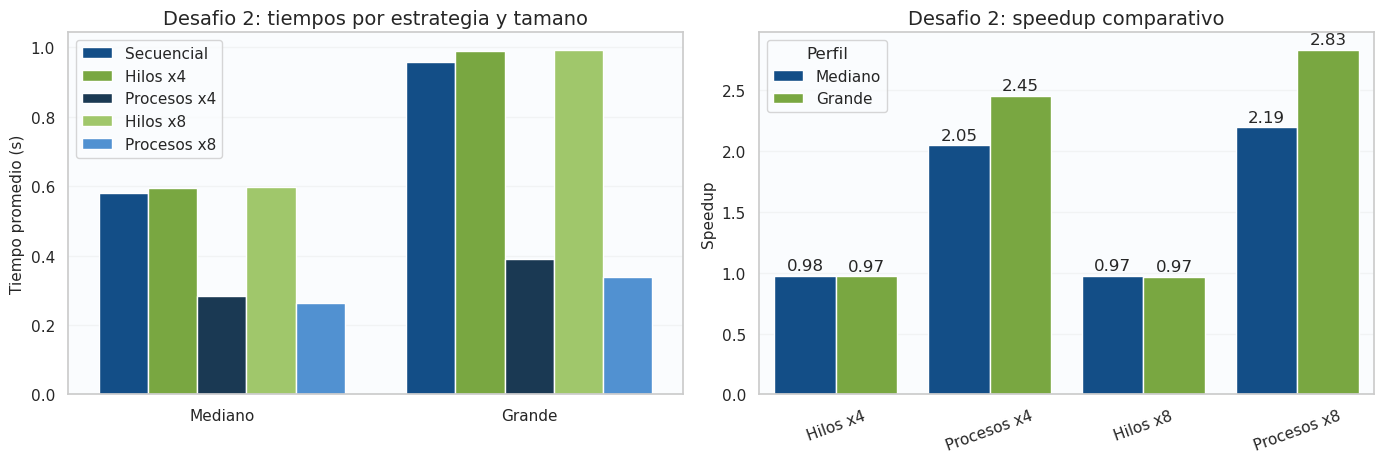

In [7]:
cpu_compare_profiles = [
    {"Perfil": "Mediano", "Bloques": 12, "Iteraciones por bloque": 300_000, "Salt": 73},
    {"Perfil": "Grande", "Bloques": 12, "Iteraciones por bloque": 500_000, "Salt": 73},
]
cpu_compare_meta = pd.DataFrame(cpu_compare_profiles)
show_df(
    cpu_compare_meta,
    "Parametros del benchmark comparativo del desafio 2",
    formats={"Bloques": "{:.0f}", "Iteraciones por bloque": fmt_int, "Salt": "{:.0f}"},
)


def run_cpu_processes(tasks, workers):
    return run_process_map(cpu_chunk_digest, tasks, workers)


d2_rows = []
for profile in cpu_compare_profiles:
    tasks = build_cpu_tasks(profile["Bloques"], profile["Iteraciones por bloque"], profile["Salt"])
    seq_stats = benchmark(lambda tasks=tasks: run_cpu_seq(tasks))

    d2_rows.append(
        {
            "Perfil": profile["Perfil"],
            "Estrategia": "Secuencial",
            "Workers": 1,
            "Tiempo medio (s)": seq_stats["mean_s"],
            "Desv. (s)": seq_stats["std_s"],
            "Speedup": 1.0,
            "Eficiencia": None,
        }
    )

    for workers in [4, 8]:
        thread_stats = benchmark(lambda tasks=tasks, workers=workers: run_cpu_threads(tasks, workers=workers))
        process_stats = benchmark(lambda tasks=tasks, workers=workers: run_cpu_processes(tasks, workers=workers))

        assert thread_stats["result"] == seq_stats["result"]
        assert process_stats["result"] == seq_stats["result"]

        d2_rows.append(
            {
                "Perfil": profile["Perfil"],
                "Estrategia": "Hilos",
                "Workers": workers,
                "Tiempo medio (s)": thread_stats["mean_s"],
                "Desv. (s)": thread_stats["std_s"],
                "Speedup": seq_stats["mean_s"] / thread_stats["mean_s"],
                "Eficiencia": (seq_stats["mean_s"] / thread_stats["mean_s"]) / workers,
            }
        )
        d2_rows.append(
            {
                "Perfil": profile["Perfil"],
                "Estrategia": "Procesos",
                "Workers": workers,
                "Tiempo medio (s)": process_stats["mean_s"],
                "Desv. (s)": process_stats["std_s"],
                "Speedup": seq_stats["mean_s"] / process_stats["mean_s"],
                "Eficiencia": (seq_stats["mean_s"] / process_stats["mean_s"]) / workers,
            }
        )

d2_df = pd.DataFrame(d2_rows)
d2_display = d2_df.copy()
d2_display["Configuracion"] = d2_display.apply(
    lambda row: row["Estrategia"] if row["Estrategia"] == "Secuencial" else f"{row['Estrategia']} x{int(row['Workers'])}",
    axis=1,
)
show_df(
    d2_display[["Perfil", "Configuracion", "Tiempo medio (s)", "Desv. (s)", "Speedup", "Eficiencia"]],
    "Desafio 2 - Benchmark comparativo secuencial, hilos y procesos",
    formats={
        "Tiempo medio (s)": "{:.4f}",
        "Desv. (s)": "{:.4f}",
        "Speedup": "{:.2f}",
        "Eficiencia": lambda value: fmt_optional(value, "{:.3f}"),
    },
    gradient_cols=["Tiempo medio (s)", "Speedup"],
)

d2_nonseq = d2_df[d2_df["Estrategia"] != "Secuencial"].copy()
d2_nonseq["Configuracion"] = d2_nonseq.apply(
    lambda row: f"{row['Estrategia']} x{int(row['Workers'])}",
    axis=1,
)

best_d2_process = d2_df[d2_df["Estrategia"] == "Procesos"].loc[
    d2_df[d2_df["Estrategia"] == "Procesos"]["Tiempo medio (s)"].idxmin()
]
best_d2_thread = d2_df[d2_df["Estrategia"] == "Hilos"].loc[
    d2_df[d2_df["Estrategia"] == "Hilos"]["Tiempo medio (s)"].idxmin()
]
metric_cards(
    [
        (
            "Mejor procesos",
            fmt_seconds(best_d2_process["Tiempo medio (s)"]),
            f"{best_d2_process['Perfil']} con {int(best_d2_process['Workers'])} procesos",
            "#004E9A",
        ),
        (
            "Mejor speedup de procesos",
            fmt_ratio(d2_df[d2_df['Estrategia'] == 'Procesos']['Speedup'].max()),
            "La granularidad ya alcanza para compensar overhead",
            "#7AB830",
        ),
        (
            "Mejor speedup de hilos",
            fmt_ratio(d2_df[d2_df['Estrategia'] == 'Hilos']['Speedup'].max()),
            "Los hilos siguen cerca de la linea base",
            "#113A5C",
        ),
    ]
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
sns.barplot(data=d2_display, x="Perfil", y="Tiempo medio (s)", hue="Configuracion", ax=axes[0])
axes[0].set_title("Desafio 2: tiempos por estrategia y tamano")
axes[0].set_ylabel("Tiempo promedio (s)")
axes[0].set_xlabel("")
axes[0].legend(title="")

sns.barplot(data=d2_nonseq, x="Configuracion", y="Speedup", hue="Perfil", ax=axes[1])
axes[1].set_title("Desafio 2: speedup comparativo")
axes[1].set_ylabel("Speedup")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=20)
for container in axes[1].containers:
    axes[1].bar_label(container, fmt="%.2f", padding=2)

plt.tight_layout()
plt.show()

In [8]:
display(
    Markdown(
        f"""
        ### Interpretacion del desafio 2

        El benchmark comparativo confirma el patron anticipado por la teoria. La mejor configuracion global fue
        **{best_d2_process['Perfil']} con {int(best_d2_process['Workers'])} procesos**, con un tiempo medio de
        **{best_d2_process['Tiempo medio (s)']:.4f} s** y speedup de **{best_d2_process['Speedup']:.2f}x**. En cambio, la mejor
        variante con hilos se mantuvo cerca de la linea base, con **{best_d2_thread['Speedup']:.2f}x** como mejor speedup.

        Este resultado responde directamente a la pregunta del laboratorio: **si la tarea es CPU-bound y las unidades son
        relativamente independientes, los procesos si ofrecen una ventaja real frente a los hilos**. Pero esa ventaja no es gratis.
        Los procesos introducen costos de creacion, serializacion y coordinacion. Por eso el speedup no es lineal y por eso el
        tamano del problema importa tanto: si la granularidad fuera demasiado fina, el overhead podria comerse la ganancia.

        En sintesis, el benchmark muestra dos ideas complementarias: el GIL deja a los hilos muy cerca del comportamiento
        secuencial en CPU puro, mientras que `ProcessPoolExecutor` recien se vuelve claramente ventajoso cuando cada bloque tiene
        suficiente trabajo como para amortizar el costo fijo del paralelismo.
        """
    )
)


        ### Interpretacion del desafio 2

        El benchmark comparativo confirma el patron anticipado por la teoria. La mejor configuracion global fue
        **Mediano con 8 procesos**, con un tiempo medio de
        **0.2639 s** y speedup de **2.19x**. En cambio, la mejor
        variante con hilos se mantuvo cerca de la linea base, con **0.98x** como mejor speedup.

        Este resultado responde directamente a la pregunta del laboratorio: **si la tarea es CPU-bound y las unidades son
        relativamente independientes, los procesos si ofrecen una ventaja real frente a los hilos**. Pero esa ventaja no es gratis.
        Los procesos introducen costos de creacion, serializacion y coordinacion. Por eso el speedup no es lineal y por eso el
        tamano del problema importa tanto: si la granularidad fuera demasiado fina, el overhead podria comerse la ganancia.

        En sintesis, el benchmark muestra dos ideas complementarias: el GIL deja a los hilos muy cerca del comportamiento
        secuencial en CPU puro, mientras que `ProcessPoolExecutor` recien se vuelve claramente ventajoso cuando cada bloque tiene
        suficiente trabajo como para amortizar el costo fijo del paralelismo.
        

## Desafio 3 - Escenario mixto con asyncio y recomendacion tecnica final

El ultimo desafio exige mas criterio. Se construye un caso mixto donde cada tarea combina una fase de espera con un postprocesamiento local. La comparacion minima es secuencial vs `asyncio`, y aqui se agrega una variante con hilos para enriquecer la interpretacion.

Perfil,Tareas,Loops locales
Dominado por espera,16,10.000
Postproceso mayor,16,50.000


Perfil,Estrategia,Tiempo medio (s),Desv. (s),Speedup,Eficiencia hilos
Dominado por espera,Secuencial,0.7099,0.0013,1.00,-
Dominado por espera,Hilos x8,0.1076,0.0003,6.60,0.825
Dominado por espera,Asyncio,0.0565,0.0019,12.56,-
Postproceso mayor,Secuencial,0.7804,0.0013,1.00,-
Postproceso mayor,Hilos x8,0.1420,0.0002,5.50,0.687
Postproceso mayor,Asyncio,0.1384,0.0084,5.64,-


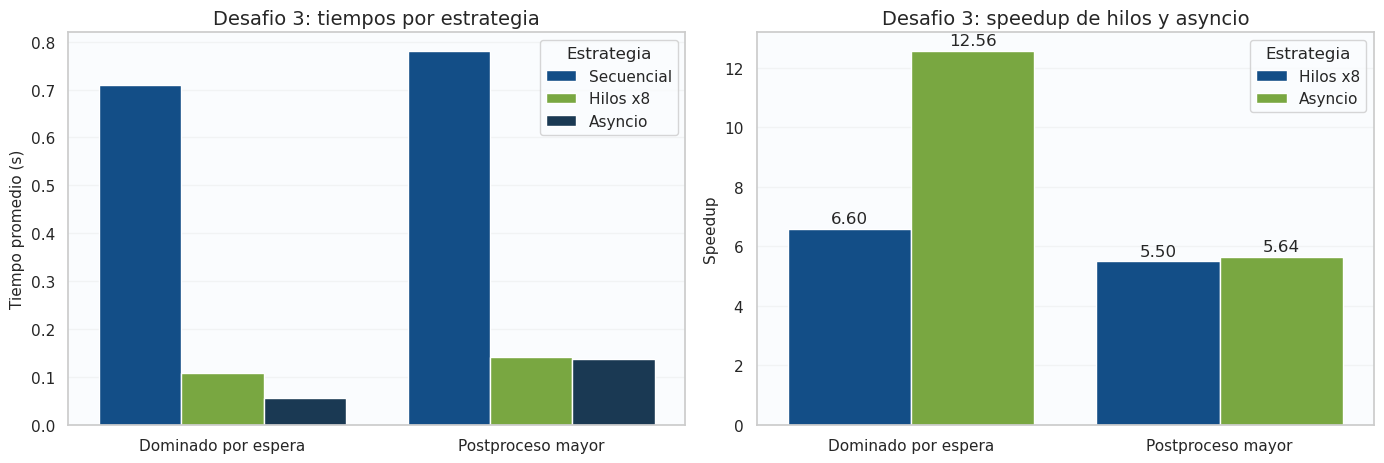

In [9]:
mixed_profiles = [
    {"Perfil": "Dominado por espera", "Tareas": 16, "Loops locales": 10_000},
    {"Perfil": "Postproceso mayor", "Tareas": 16, "Loops locales": 50_000},
]
mixed_meta = pd.DataFrame(mixed_profiles)
show_df(
    mixed_meta,
    "Parametros del escenario mixto del desafio 3",
    formats={"Tareas": "{:.0f}", "Loops locales": fmt_int},
)


def local_transform(task_id, loops):
    acc = 0
    seed = (task_id + 3) * 7_919
    for i in range(loops):
        acc += ((seed + i * 7) % 131) * ((i % 13) + 1)
    return acc


def mixed_sync_task(task):
    task_id, loops = task
    time.sleep(0.035 + (task_id % 4) * 0.005)
    return task_id, local_transform(task_id, loops)


async def mixed_async_task(task):
    task_id, loops = task
    await asyncio.sleep(0.035 + (task_id % 4) * 0.005)
    return task_id, local_transform(task_id, loops)


def run_mixed_seq(tasks):
    return [mixed_sync_task(task) for task in tasks]


def run_mixed_threads(tasks, workers=8):
    return run_thread_map(mixed_sync_task, tasks, workers)


async def run_mixed_async(tasks):
    return await asyncio.gather(*(mixed_async_task(task) for task in tasks))


d3_rows = []
for profile in mixed_profiles:
    tasks = [(task_id, profile["Loops locales"]) for task_id in range(profile["Tareas"])]

    seq_stats = benchmark(lambda tasks=tasks: run_mixed_seq(tasks))
    thread_stats = benchmark(lambda tasks=tasks: run_mixed_threads(tasks, workers=8))
    async_stats = await benchmark_async(lambda tasks=tasks: run_mixed_async(tasks))

    assert seq_stats["result"] == thread_stats["result"]
    assert seq_stats["result"] == async_stats["result"]

    d3_rows.append(
        {
            "Perfil": profile["Perfil"],
            "Estrategia": "Secuencial",
            "Tiempo medio (s)": seq_stats["mean_s"],
            "Desv. (s)": seq_stats["std_s"],
            "Speedup": 1.0,
            "Eficiencia hilos": None,
        }
    )
    d3_rows.append(
        {
            "Perfil": profile["Perfil"],
            "Estrategia": "Hilos x8",
            "Tiempo medio (s)": thread_stats["mean_s"],
            "Desv. (s)": thread_stats["std_s"],
            "Speedup": seq_stats["mean_s"] / thread_stats["mean_s"],
            "Eficiencia hilos": (seq_stats["mean_s"] / thread_stats["mean_s"]) / 8,
        }
    )
    d3_rows.append(
        {
            "Perfil": profile["Perfil"],
            "Estrategia": "Asyncio",
            "Tiempo medio (s)": async_stats["mean_s"],
            "Desv. (s)": async_stats["std_s"],
            "Speedup": seq_stats["mean_s"] / async_stats["mean_s"],
            "Eficiencia hilos": None,
        }
    )

d3_df = pd.DataFrame(d3_rows)
show_df(
    d3_df,
    "Desafio 3 - Secuencial, hilos y asyncio en un escenario mixto",
    formats={
        "Tiempo medio (s)": "{:.4f}",
        "Desv. (s)": "{:.4f}",
        "Speedup": "{:.2f}",
        "Eficiencia hilos": lambda value: fmt_optional(value, "{:.3f}"),
    },
    gradient_cols=["Tiempo medio (s)", "Speedup"],
)

best_d3_async = d3_df[d3_df["Estrategia"] == "Asyncio"].loc[
    d3_df[d3_df["Estrategia"] == "Asyncio"]["Tiempo medio (s)"].idxmin()
]
best_d3_threads = d3_df[d3_df["Estrategia"] == "Hilos x8"].loc[
    d3_df[d3_df["Estrategia"] == "Hilos x8"]["Tiempo medio (s)"].idxmin()
]
metric_cards(
    [
        (
            "Mejor tiempo con asyncio",
            fmt_seconds(best_d3_async["Tiempo medio (s)"]),
            f"Perfil: {best_d3_async['Perfil']}",
            "#004E9A",
        ),
        (
            "Mejor tiempo con hilos",
            fmt_seconds(best_d3_threads["Tiempo medio (s)"]),
            f"Perfil: {best_d3_threads['Perfil']}",
            "#7AB830",
        ),
        (
            "Lectura principal",
            "El peso del postproceso importa",
            "Cuando crece el computo local, la ventaja de asyncio se estrecha",
            "#113A5C",
        ),
    ]
)

d3_nonseq = d3_df[d3_df["Estrategia"] != "Secuencial"].copy()
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
sns.barplot(data=d3_df, x="Perfil", y="Tiempo medio (s)", hue="Estrategia", ax=axes[0])
axes[0].set_title("Desafio 3: tiempos por estrategia")
axes[0].set_ylabel("Tiempo promedio (s)")
axes[0].set_xlabel("")

sns.barplot(data=d3_nonseq, x="Perfil", y="Speedup", hue="Estrategia", ax=axes[1])
axes[1].set_title("Desafio 3: speedup de hilos y asyncio")
axes[1].set_ylabel("Speedup")
axes[1].set_xlabel("")
for container in axes[1].containers:
    axes[1].bar_label(container, fmt="%.2f", padding=2)

plt.tight_layout()
plt.show()

In [10]:
d3_wait_profile = d3_df[d3_df["Perfil"] == "Dominado por espera"].copy()
d3_compute_profile = d3_df[d3_df["Perfil"] == "Postproceso mayor"].copy()
async_wait_speedup = float(d3_wait_profile[d3_wait_profile["Estrategia"] == "Asyncio"]["Speedup"].iloc[0])
async_compute_speedup = float(d3_compute_profile[d3_compute_profile["Estrategia"] == "Asyncio"]["Speedup"].iloc[0])

display(
    Markdown(
        f"""
        ### Interpretacion del desafio 3

        El caso mixto muestra un matiz importante. Cuando el perfil estuvo **dominado por espera**, `asyncio` alcanzo un speedup de
        **{async_wait_speedup:.2f}x** y fue la estrategia mas rapida. Eso tiene sentido porque el event loop coordina muy bien una
        gran cantidad de esperas no bloqueantes sin el costo de crear threads o procesos adicionales.

        Cuando aumentamos el **postproceso local**, el speedup de `asyncio` bajo a **{async_compute_speedup:.2f}x**. La razon es
        tecnica: `asyncio` es excelente para administrar espera, pero no convierte automaticamente el computo local en paralelismo.
        A medida que la fase CPU crece, la ventaja de la asincronia se estrecha y los hilos pueden acercarse o incluso competir en
        tiempo total si la parte de espera ya no domina tanto.

        La lectura correcta no es que `asyncio` sea "mejor siempre", sino que su ventaja depende de que el problema este realmente
        dominado por espera no bloqueante. Ese es precisamente el tipo de criterio que el laboratorio pide defender.
        """
    )
)

final_recommendation = f"""
## Recomendacion tecnica final

A partir del conjunto de experimentos, los criterios que usaria para decidir entre una solucion secuencial, basada en hilos,
basada en procesos o asincrona son los siguientes. Primero, identificaria la **naturaleza de la carga**. Si el cuello de botella
esta en computo puro y el trabajo sucede en Python, los hilos no son una buena apuesta inicial porque el GIL impide paralelismo
efectivo de bytecode. En ese escenario, los procesos son mas adecuados siempre que las unidades de trabajo sean lo bastante grandes
como para amortizar el overhead de creacion, serializacion y coordinacion. Eso se vio con claridad en el desafio 2, donde procesos
alcanzo hasta **{d2_df[d2_df['Estrategia'] == 'Procesos']['Speedup'].max():.2f}x** y los hilos quedaron cerca de la linea base.

Segundo, si la carga esta dominada por **espera o latencia**, preferiria hilos o `asyncio` antes que procesos. En el desafio 1.b,
los hilos lograron hasta **{d1b_df['Speedup hilos'].max():.2f}x**, precisamente porque lograron solapar la espera. En el desafio 3,
`asyncio` fue especialmente fuerte cuando la fase de espera fue dominante, pero su ventaja se redujo cuando el postproceso local
aumento. Eso demuestra que la asincronia no reemplaza al paralelismo de CPU; simplemente administra mejor las esperas.

Tercero, consideraria el **tamano del problema y la granularidad**. Un benchmark mal interpretado puede llevar a pensar que una
tecnica "no sirve", cuando en realidad el problema era demasiado pequeno y el overhead se comio la ganancia. Tambien registraria
siempre restricciones del entorno: sistema operativo, version de Python, numero de nucleos, limite del GIL y costos del runtime.

En sintesis, usaria secuencial para casos pequenos o fuertemente acoplados, hilos para I/O-bound, procesos para CPU-bound de grano
suficiente y `asyncio` para alta concurrencia no bloqueante. La eleccion correcta no depende del gusto por una tecnologia, sino de
la evidencia que entrega el benchmark y de la estructura real del problema.
"""
display(Markdown(final_recommendation))


        ### Interpretacion del desafio 3

        El caso mixto muestra un matiz importante. Cuando el perfil estuvo **dominado por espera**, `asyncio` alcanzo un speedup de
        **12.56x** y fue la estrategia mas rapida. Eso tiene sentido porque el event loop coordina muy bien una
        gran cantidad de esperas no bloqueantes sin el costo de crear threads o procesos adicionales.

        Cuando aumentamos el **postproceso local**, el speedup de `asyncio` bajo a **5.64x**. La razon es
        tecnica: `asyncio` es excelente para administrar espera, pero no convierte automaticamente el computo local en paralelismo.
        A medida que la fase CPU crece, la ventaja de la asincronia se estrecha y los hilos pueden acercarse o incluso competir en
        tiempo total si la parte de espera ya no domina tanto.

        La lectura correcta no es que `asyncio` sea "mejor siempre", sino que su ventaja depende de que el problema este realmente
        dominado por espera no bloqueante. Ese es precisamente el tipo de criterio que el laboratorio pide defender.
        


## Recomendacion tecnica final

A partir del conjunto de experimentos, los criterios que usaria para decidir entre una solucion secuencial, basada en hilos,
basada en procesos o asincrona son los siguientes. Primero, identificaria la **naturaleza de la carga**. Si el cuello de botella
esta en computo puro y el trabajo sucede en Python, los hilos no son una buena apuesta inicial porque el GIL impide paralelismo
efectivo de bytecode. En ese escenario, los procesos son mas adecuados siempre que las unidades de trabajo sean lo bastante grandes
como para amortizar el overhead de creacion, serializacion y coordinacion. Eso se vio con claridad en el desafio 2, donde procesos
alcanzo hasta **2.83x** y los hilos quedaron cerca de la linea base.

Segundo, si la carga esta dominada por **espera o latencia**, preferiria hilos o `asyncio` antes que procesos. En el desafio 1.b,
los hilos lograron hasta **7.10x**, precisamente porque lograron solapar la espera. En el desafio 3,
`asyncio` fue especialmente fuerte cuando la fase de espera fue dominante, pero su ventaja se redujo cuando el postproceso local
aumento. Eso demuestra que la asincronia no reemplaza al paralelismo de CPU; simplemente administra mejor las esperas.

Tercero, consideraria el **tamano del problema y la granularidad**. Un benchmark mal interpretado puede llevar a pensar que una
tecnica "no sirve", cuando en realidad el problema era demasiado pequeno y el overhead se comio la ganancia. Tambien registraria
siempre restricciones del entorno: sistema operativo, version de Python, numero de nucleos, limite del GIL y costos del runtime.

En sintesis, usaria secuencial para casos pequenos o fuertemente acoplados, hilos para I/O-bound, procesos para CPU-bound de grano
suficiente y `asyncio` para alta concurrencia no bloqueante. La eleccion correcta no depende del gusto por una tecnologia, sino de
la evidencia que entrega el benchmark y de la estructura real del problema.


In [11]:
summary_payload = {
    "metadata": {
        "os": platform.platform(),
        "python": platform.python_version(),
        "logical_cpus": os.cpu_count(),
        "ram_gb": round(psutil.virtual_memory().total / 1024**3, 2) if psutil else None,
    },
    "challenge1_cpu": {
        "rows": to_json_records(d1a_df),
        "best_speedup": float(d1a_df["Speedup hilos"].max()),
        "mean_speedup": float(d1a_df["Speedup hilos"].mean()),
        "best_profile": str(best_d1a["Perfil"]),
    },
    "challenge1_io": {
        "rows": to_json_records(d1b_df),
        "best_speedup": float(d1b_df["Speedup hilos"].max()),
        "best_efficiency": float(d1b_df["Eficiencia hilos"].max()),
        "best_profile": str(best_d1b["Perfil"]),
    },
    "challenge2": {
        "rows": to_json_records(d2_df),
        "best_process_profile": str(best_d2_process["Perfil"]),
        "best_process_workers": int(best_d2_process["Workers"]),
        "best_process_time": float(best_d2_process["Tiempo medio (s)"]),
        "best_process_speedup": float(best_d2_process["Speedup"]),
        "best_thread_speedup": float(d2_df[d2_df["Estrategia"] == "Hilos"]["Speedup"].max()),
    },
    "challenge3": {
        "rows": to_json_records(d3_df),
        "best_async_profile": str(best_d3_async["Perfil"]),
        "best_async_time": float(best_d3_async["Tiempo medio (s)"]),
        "best_async_speedup": float(d3_df[d3_df["Estrategia"] == "Asyncio"]["Speedup"].max()),
        "best_thread_time": float(best_d3_threads["Tiempo medio (s)"]),
        "best_thread_speedup": float(d3_df[d3_df["Estrategia"] == "Hilos x8"]["Speedup"].max()),
        "async_wait_speedup": async_wait_speedup,
        "async_compute_speedup": async_compute_speedup,
    },
}

with SUMMARY_PATH.open("w", encoding="utf-8") as summary_file:
    json.dump(summary_payload, summary_file, indent=2)

callout(
    "Exportacion interna completada",
    f"Se genero el archivo de resumen en <code>{SUMMARY_PATH.name}</code> para construir automaticamente la guia de presentacion.",
    accent="#004E9A",
    bg="#F5F9FE",
)